

# გარემოს მომზადება

In [2]:
!pip install -q dagshub mlflow==2.22.0 prophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import mlflow

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open walmart-recruiting-store-sales-forecasting.zip, walmart-recruiting-store-sales-forecasting.zip.zip or walmart-recruiting-store-sales-forecasting.zip.ZIP.


In [6]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [7]:
!kaggle competitions list

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token


In [8]:
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast


Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
100% 3.36M/3.36M [00:00<00:00, 21.2MB/s]



In [9]:
!unzip -o walmart-sales-forecast.zip -d data/


Archive:  walmart-sales-forecast.zip
  inflating: data/features.csv       
  inflating: data/stores.csv         
  inflating: data/test.csv           
  inflating: data/train.csv          


In [10]:
import pandas as pd
import numpy as np

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
features = pd.read_csv('data/features.csv')
stores = pd.read_csv('data/stores.csv')

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [12]:
import dagshub
import mlflow

dagshub.init(
    repo_owner='aleko-mamukashvili',
    repo_name='Store-Sales-Forecasting',
    mlflow=True
)

EXPERIMENT_NAME = "Prophet_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6fd59318-b557-46d0-b7f9-98ee96cd2a76&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3c96fc217dcb82f1ebf6dc804423af9dab106a60a0b58abce1bba4e17efa3513




Accessing as ndoda23

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/ebf87c7ad3834af08b1118eb4cc72722', creation_time=1783783149263, experiment_id='3', last_update_time=1783783149263, lifecycle_stage='active', name='Prophet_Training', tags={}>

In [13]:
DATA_PATH = "data"

train_raw = pd.read_csv(f"{DATA_PATH}/train.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

df = train_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
df = df.merge(stores_raw, on='Store', how='left')

if 'IsHoliday_feat' in df.columns:
    df = df.drop(columns=['IsHoliday_feat'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [14]:
agg = df.groupby('Date').agg(
    y=('Weekly_Sales', 'sum'),
    IsHoliday=('IsHoliday', 'max'),
    Temperature=('Temperature', 'mean'),
    Fuel_Price=('Fuel_Price', 'mean'),
    CPI=('CPI', 'mean'),
    Unemployment=('Unemployment', 'mean'),
).reset_index().rename(columns={'Date': 'ds'})

print(agg.shape)
agg.head()

(143, 7)


,ds,y,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,False,33.277942,2.717869,167.398405,8.576731
1,2010-02-12,48336677.63,True,33.361810,2.696102,167.384138,8.567309
2,2010-02-19,48276993.78,False,37.038310,2.673666,167.338966,8.576351
3,2010-02-26,43968571.13,False,38.629563,2.685642,167.691019,8.561375
4,2010-03-05,46871470.30,False,42.373998,2.731816,167.727351,8.572689


# EDA - გადაწყვეტილებები

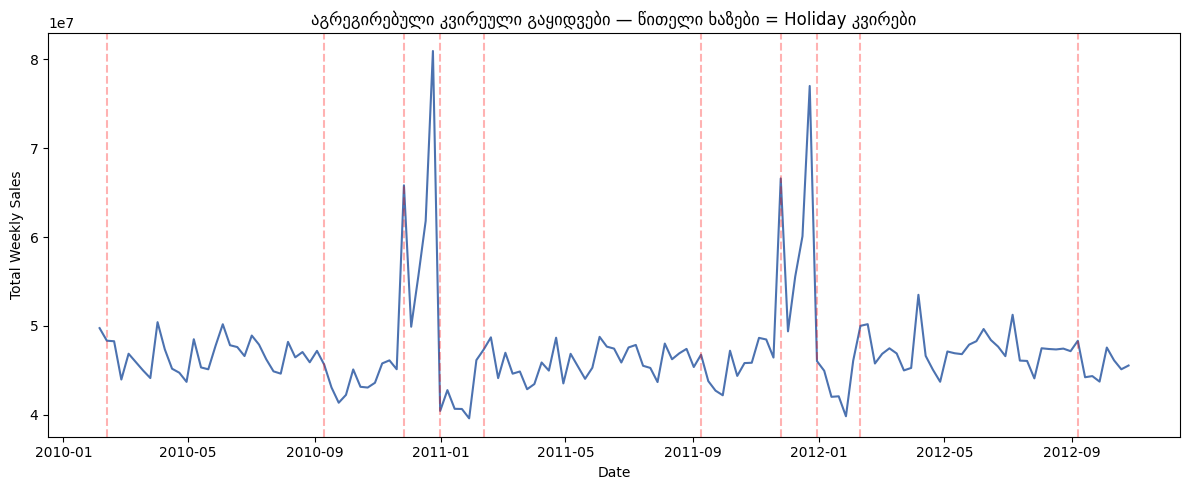

In [15]:
fig, ax = plt.subplots()
ax.plot(agg['ds'], agg['y'], color='#4C72B0')
holiday_dates = agg[agg['IsHoliday']]['ds']
for hd in holiday_dates:
    ax.axvline(hd, color='red', alpha=0.3, linestyle='--')
ax.set_title('აგრეგირებული კვირეული გაყიდვები — წითელი ხაზები = Holiday კვირები')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales')
plt.tight_layout()
plt.show()

# Seasonal Decomposition

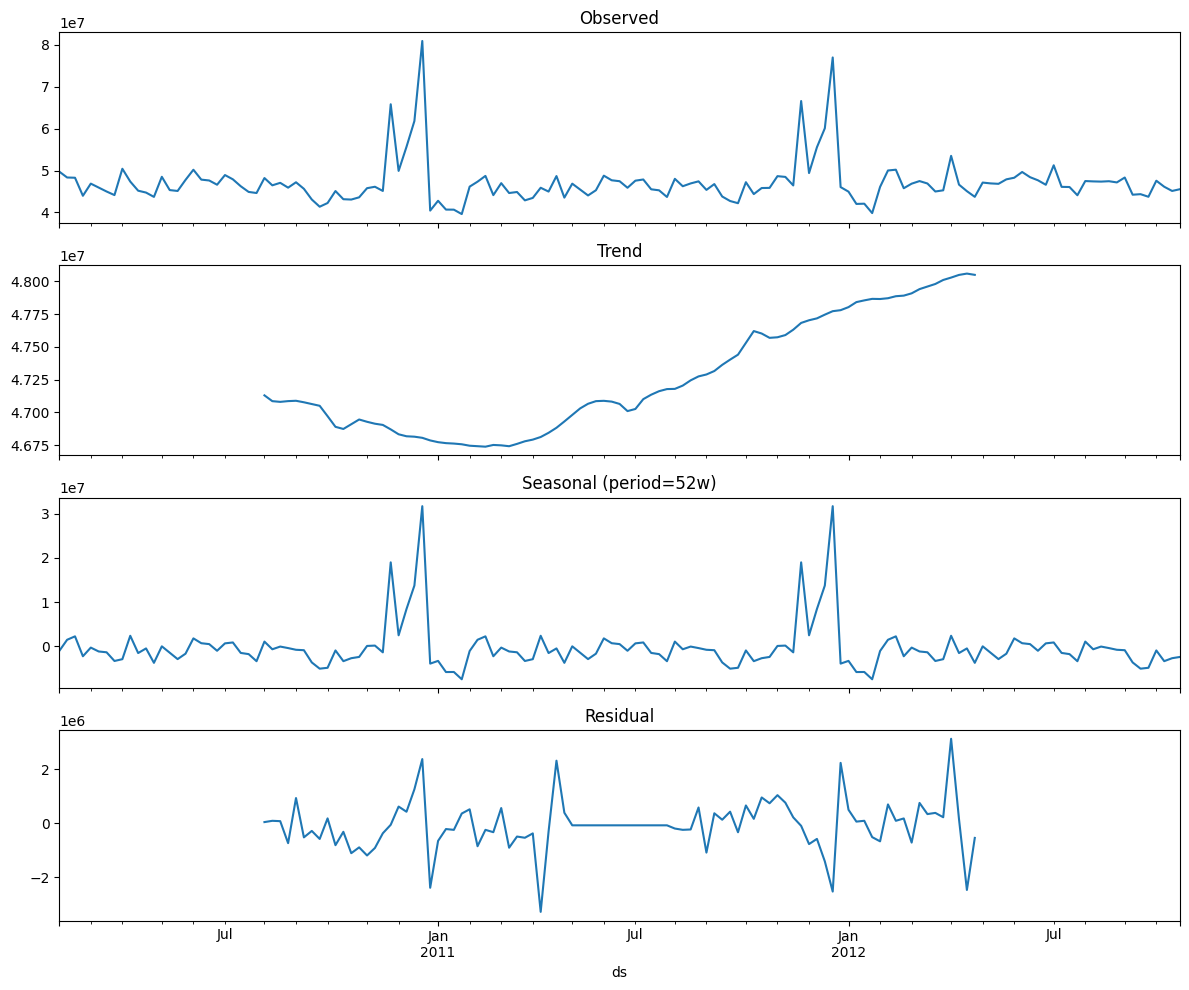

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

agg_indexed = agg.set_index('ds')['y']
decomposition = seasonal_decompose(agg_indexed, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (period=52w)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

/tmp/ipykernel_539/3844583738.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_sales, holiday_sales], labels=['Non-Holiday', 'Holiday'])


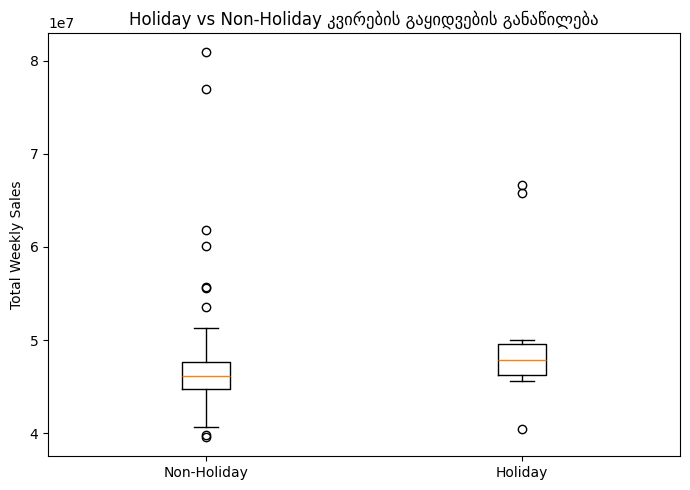

Holiday საშუალო: 50529955.156
Non-Holiday საშუალო: 46856537.10939851


In [17]:
holiday_sales = agg[agg['IsHoliday']]['y']
normal_sales = agg[~agg['IsHoliday']]['y']

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([normal_sales, holiday_sales], labels=['Non-Holiday', 'Holiday'])
ax.set_ylabel('Total Weekly Sales')
ax.set_title('Holiday vs Non-Holiday კვირების გაყიდვების განაწილება')
plt.tight_layout()
plt.show()

print("Holiday საშუალო:", holiday_sales.mean())
print("Non-Holiday საშუალო:", normal_sales.mean())

# გარე ცვლადების კორელაცია

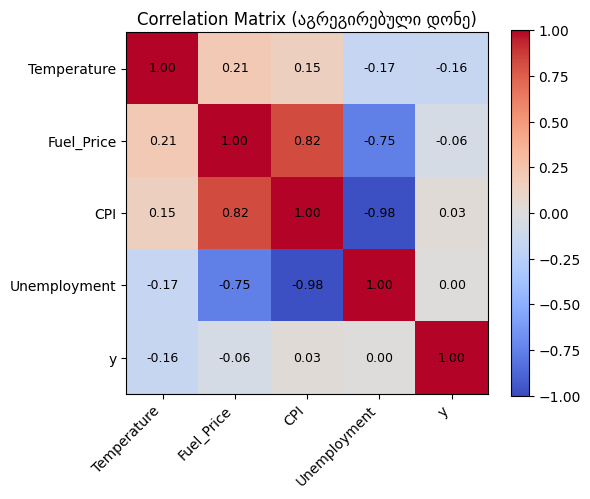

In [18]:
numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'y']
corr_matrix = agg[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
ax.set_title('Correlation Matrix (აგრეგირებული დონე)')
plt.tight_layout()
plt.show()

# Train/Validation split

In [19]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

train_agg = agg[agg['ds'] < VAL_START].copy()
val_agg = agg[(agg['ds'] >= VAL_START) & (agg['ds'] <= VAL_END)].copy()

print(f"Train: {train_agg.shape} | {train_agg['ds'].min().date()} -> {train_agg['ds'].max().date()}")
print(f"Val:   {val_agg.shape} | {val_agg['ds'].min().date()} -> {val_agg['ds'].max().date()}")
print(f"Holiday კვირები val-ში: {sorted(val_agg[val_agg['IsHoliday']]['ds'].dt.date.unique())}")

Train: (91, 7) | 2010-02-05 -> 2011-10-28
Val:   (15, 7) | 2011-11-04 -> 2012-02-10
Holiday კვირები val-ში: [datetime.date(2011, 11, 25), datetime.date(2011, 12, 30), datetime.date(2012, 2, 10)]


# Feature Engineering

In [20]:
holiday_dates_all = sorted(agg[agg['IsHoliday']]['ds'].dt.date.unique())
print("ყველა holiday თარიღი მონაცემებში:", holiday_dates_all)

walmart_holidays = pd.DataFrame({
    'holiday': 'walmart_event',
    'ds': pd.to_datetime(holiday_dates_all),
    'lower_window': 0,
    'upper_window': 0,
})
walmart_holidays

ყველა holiday თარიღი მონაცემებში: [datetime.date(2010, 2, 12), datetime.date(2010, 9, 10), datetime.date(2010, 11, 26), datetime.date(2010, 12, 31), datetime.date(2011, 2, 11), datetime.date(2011, 9, 9), datetime.date(2011, 11, 25), datetime.date(2011, 12, 30), datetime.date(2012, 2, 10), datetime.date(2012, 9, 7)]


,holiday,ds,lower_window,upper_window
0,walmart_event,2010-02-12,0,0
1,walmart_event,2010-09-10,0,0
2,walmart_event,2010-11-26,0,0
3,walmart_event,2010-12-31,0,0
4,walmart_event,2011-02-11,0,0
5,walmart_event,2011-09-09,0,0
6,walmart_event,2011-11-25,0,0
7,walmart_event,2011-12-30,0,0
8,walmart_event,2012-02-10,0,0
9,walmart_event,2012-09-07,0,0


# Extra Regressors

In [21]:
REGRESSOR_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in REGRESSOR_COLS:
    train_agg[col] = train_agg[col].fillna(train_agg[col].mean())
    val_agg[col] = val_agg[col].fillna(train_agg[col].mean())

print("Regressor სვეტები მზადაა:", REGRESSOR_COLS)

Regressor სვეტები მზადაა: ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


# მეტრიკები და MLflow loggin helper-ები

In [22]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(np.asarray(y_true) - y_pred)) / np.sum(weights)

def evaluate_prophet(model, train_df, val_df):
    train_forecast = model.predict(train_df.drop(columns=['y']))
    val_forecast = model.predict(val_df.drop(columns=['y']))
    return {
        'wmae_train': wmae(train_df['y'], train_forecast['yhat'].values, train_df['IsHoliday']),
        'wmae_val': wmae(val_df['y'], val_forecast['yhat'].values, val_df['IsHoliday']),
    }, train_forecast, val_forecast

def plot_prophet_forecast(train_df, val_df, train_forecast, val_forecast, title):
    fig, ax = plt.subplots()
    ax.plot(train_df['ds'], train_df['y'], color='#4C72B0', label='Actual (Train)')
    ax.plot(val_df['ds'], val_df['y'], color='#C44E52', label='Actual (Val)')
    ax.plot(train_df['ds'], train_forecast['yhat'], color='#4C72B0', linestyle='--', alpha=0.6, label='Predicted (Train)')
    ax.plot(val_df['ds'], val_forecast['yhat'], color='#C44E52', linestyle='--', alpha=0.9, label='Predicted (Val)')
    ax.axvline(train_df['ds'].max(), color='gray', linestyle=':', label='Train/Val Split')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [23]:
def log_run(run_name, params, metrics, model=None, registered_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if model is not None:
            mlflow.prophet.log_model(
                model, "model",
                registered_model_name=registered_name
            )
        print(run_name, "->", metrics)

# ექსპერიმენტები და MLflowზე დალოგვა

## Run1 baseline

In [24]:
m1 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m1.fit(train_agg[['ds', 'y']])

metrics1, tr_fc1, val_fc1 = evaluate_prophet(m1, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics1)

{'wmae_train': np.float64(2561563.990786997), 'wmae_val': np.float64(6659329.814776104)}


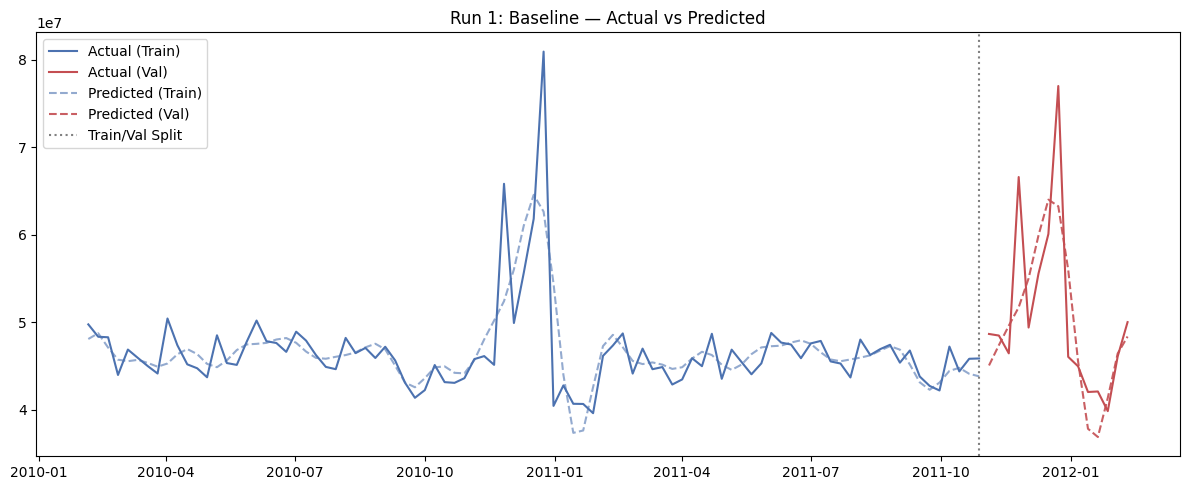

In [26]:
plot_prophet_forecast(train_agg, val_agg, tr_fc1, val_fc1, 'Run 1: Baseline — Actual vs Predicted')

In [25]:
log_run(
    "Prophet_Baseline",
    params={'yearly_seasonality': True, 'weekly_seasonality': False, 'holidays': False},
    metrics=metrics1,
    model=m1,
)

2026/07/11 19:25:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_Baseline -> {'wmae_train': np.float64(2561563.990786997), 'wmae_val': np.float64(6659329.814776104)}
🏃 View run Prophet_Baseline at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/cb6f8a27d9d84b7b8a7e2a1e7e14c105
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


##  Run2 Weekly Seasonality

In [27]:
m2 = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m2.fit(train_agg[['ds', 'y']])

metrics2, tr_fc2, val_fc2 = evaluate_prophet(m2, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics2)

{'wmae_train': np.float64(2562693.584705726), 'wmae_val': np.float64(6660521.294937594)}


In [28]:
log_run(
    "Prophet_WeeklySeasonality",
    params={'yearly_seasonality': True, 'weekly_seasonality': True, 'holidays': False},
    metrics=metrics2,
    model=m2,
)

2026/07/11 19:26:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_WeeklySeasonality -> {'wmae_train': np.float64(2562693.584705726), 'wmae_val': np.float64(6660521.294937594)}
🏃 View run Prophet_WeeklySeasonality at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/066b9c19d33f469a9b29f2ee95c4a06a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Run3 Custom Walmart Holidays

In [29]:
m3 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays)
m3.fit(train_agg[['ds', 'y']])

metrics3, tr_fc3, val_fc3 = evaluate_prophet(m3, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics3)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2561295.8412701995), 'wmae_val': np.float64(6659767.8073674925)}


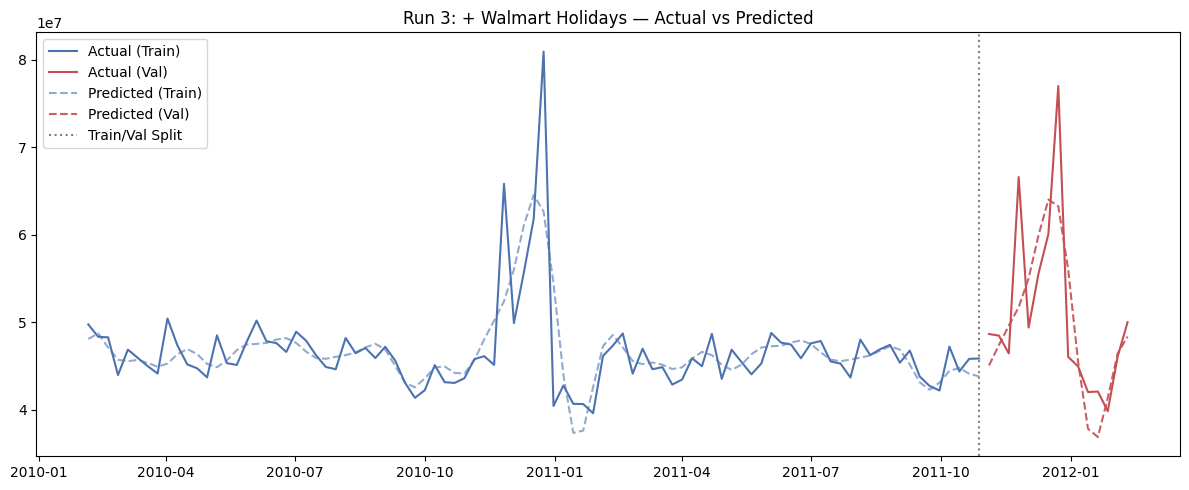

In [30]:
plot_prophet_forecast(train_agg, val_agg, tr_fc3, val_fc3, 'Run 3: + Walmart Holidays — Actual vs Predicted')

In [31]:
log_run(
    "Prophet_WalmartHolidays",
    params={'yearly_seasonality': True, 'weekly_seasonality': False, 'holidays': 'walmart_custom'},
    metrics=metrics3,
    model=m3,
)

2026/07/11 19:27:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_WalmartHolidays -> {'wmae_train': np.float64(2561295.8412701995), 'wmae_val': np.float64(6659767.8073674925)}
🏃 View run Prophet_WalmartHolidays at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/c50604a098a547a5bbf8bfa51b4f544c
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Run 4 Regressor : Temperature

In [32]:
m4 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays)
m4.add_regressor('Temperature')
m4.fit(train_agg[['ds', 'y', 'Temperature']])

metrics4, tr_fc4, val_fc4 = evaluate_prophet(
    m4,
    train_agg[['ds', 'y', 'IsHoliday', 'Temperature']],
    val_agg[['ds', 'y', 'IsHoliday', 'Temperature']],
)
print(metrics4)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2490822.462195109), 'wmae_val': np.float64(6500853.565718852)}


In [33]:
log_run(
    "Prophet_PlusTemperature",
    params={'holidays': 'walmart_custom', 'regressors': 'Temperature'},
    metrics=metrics4,
    model=m4,
)

2026/07/11 19:29:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_PlusTemperature -> {'wmae_train': np.float64(2490822.462195109), 'wmae_val': np.float64(6500853.565718852)}
🏃 View run Prophet_PlusTemperature at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/9264530b8330494284cc748f9d5c0485
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Run5 Regressors : FuelPrice,CPI,Unemployment

In [34]:
m5 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays)
for col in ['Fuel_Price', 'CPI', 'Unemployment']:
    m5.add_regressor(col)
m5.fit(train_agg[['ds', 'y', 'Fuel_Price', 'CPI', 'Unemployment']])

metrics5, tr_fc5, val_fc5 = evaluate_prophet(
    m5,
    train_agg[['ds', 'y', 'IsHoliday', 'Fuel_Price', 'CPI', 'Unemployment']],
    val_agg[['ds', 'y', 'IsHoliday', 'Fuel_Price', 'CPI', 'Unemployment']],
)
print(metrics5)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2472909.734376142), 'wmae_val': np.float64(6362467.006523611)}


In [35]:
log_run(
    "Prophet_PlusEconomicRegressors",
    params={'holidays': 'walmart_custom', 'regressors': 'Fuel_Price,CPI,Unemployment'},
    metrics=metrics5,
    model=m5,
)

2026/07/11 19:38:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_PlusEconomicRegressors -> {'wmae_train': np.float64(2472909.734376142), 'wmae_val': np.float64(6362467.006523611)}
🏃 View run Prophet_PlusEconomicRegressors at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/445f308fe49b4154b4fe39071668c49e
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Changpoint prior scale = 0.5

In [36]:
m6 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays,
             changepoint_prior_scale=0.5)
m6.fit(train_agg[['ds', 'y']])

metrics6, tr_fc6, val_fc6 = evaluate_prophet(m6, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics6)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2528523.258492349), 'wmae_val': np.float64(6682232.761912491)}


In [37]:
log_run(
    "Prophet_ChangepointFlexible",
    params={'holidays': 'walmart_custom', 'changepoint_prior_scale': 0.5},
    metrics=metrics6,
    model=m6,
)

2026/07/11 19:45:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_ChangepointFlexible -> {'wmae_train': np.float64(2528523.258492349), 'wmae_val': np.float64(6682232.761912491)}
🏃 View run Prophet_ChangepointFlexible at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/fbae77e19a8347a28c230fa5d23f4395
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Changepoint prior scale = 0.01

In [38]:
m7 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays,
             changepoint_prior_scale=0.01)
m7.fit(train_agg[['ds', 'y']])

metrics7, tr_fc7, val_fc7 = evaluate_prophet(m7, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics7)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2563460.6441286574), 'wmae_val': np.float64(6663052.082837552)}


In [39]:
log_run(
    "Prophet_ChangepointRigid",
    params={'holidays': 'walmart_custom', 'changepoint_prior_scale': 0.01},
    metrics=metrics7,
    model=m7,
)

2026/07/11 19:45:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_ChangepointRigid -> {'wmae_train': np.float64(2563460.6441286574), 'wmae_val': np.float64(6663052.082837552)}
🏃 View run Prophet_ChangepointRigid at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/e433f76bc07c4ebeb1794affdeb21748
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## Seasonality Mode = Multiplicative

In [40]:
m8 = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays,
             seasonality_mode='multiplicative')
m8.fit(train_agg[['ds', 'y']])

metrics8, tr_fc8, val_fc8 = evaluate_prophet(m8, train_agg[['ds', 'y', 'IsHoliday']], val_agg[['ds', 'y', 'IsHoliday']])
print(metrics8)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_train': np.float64(2563074.324853975), 'wmae_val': np.float64(6653438.538655668)}


In [42]:
log_run(
    "Prophet_MultiplicativeSeasonality",
    params={'holidays': 'walmart_custom', 'seasonality_mode': 'multiplicative'},
    metrics=metrics8,
    model=m8,
)

2026/07/11 19:50:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Prophet_MultiplicativeSeasonality -> {'wmae_train': np.float64(2563074.324853975), 'wmae_val': np.float64(6653438.538655668)}
🏃 View run Prophet_MultiplicativeSeasonality at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/d2f0a711f2ad4b5eaca6b75596d79eca
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3



## Prophetის ჩაშენებული Cross Validation

In [41]:
cv_results = cross_validation(
    m3,  #ჯერჯერობით საუკეთესო  არჩეული base მოდელი (holidays-ით)
    initial='365 days',
    period='90 days',
    horizon='90 days',
)
cv_metrics_df = performance_metrics(cv_results)
print(cv_metrics_df[['horizon', 'mae', 'rmse']].head(10))

cv_summary = {
    'cv_mae_mean': float(cv_metrics_df['mae'].mean()),
    'cv_rmse_mean': float(cv_metrics_df['rmse'].mean()),
}
print(cv_summary)

INFO:prophet:Making 2 forecasts with cutoffs between 2011-05-01 00:00:00 and 2011-07-30 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

  horizon           mae          rmse
0  6 days  3.339548e+06  3.340532e+06
1 12 days  2.050019e+06  2.466003e+06
2 13 days  1.003912e+06  1.055057e+06
3 19 days  1.788372e+06  1.846572e+06
4 20 days  1.603828e+06  1.728478e+06
5 26 days  1.285959e+06  1.326791e+06
6 27 days  1.072955e+06  1.201013e+06
7 33 days  1.322130e+06  1.539559e+06
8 34 days  1.576541e+06  1.664650e+06
9 40 days  1.068832e+06  1.069165e+06
{'cv_mae_mean': 1671017.8982229256, 'cv_rmse_mean': 1854779.0912688703}


In [43]:
log_run(
    "Prophet_CrossValidation",
    params={'initial': '365 days', 'period': '90 days', 'horizon': '90 days'},
    metrics=cv_summary,
    model=None,
)

Prophet_CrossValidation -> {'cv_mae_mean': 1671017.8982229256, 'cv_rmse_mean': 1854779.0912688703}
🏃 View run Prophet_CrossValidation at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/b46d8a9ce96e48c996732aec24b629ff
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


## საბოლოო მოდელი

In [44]:
all_runs = {
    'Baseline': metrics1['wmae_val'],
    'WeeklySeasonality': metrics2['wmae_val'],
    'WalmartHolidays': metrics3['wmae_val'],
    'PlusTemperature': metrics4['wmae_val'],
    'PlusEconomicRegressors': metrics5['wmae_val'],
    'ChangepointFlexible': metrics6['wmae_val'],
    'ChangepointRigid': metrics7['wmae_val'],
    'MultiplicativeSeasonality': metrics8['wmae_val'],
}
for name, wmae_val in sorted(all_runs.items(), key=lambda x: x[1]):
    print(f"{name}: {wmae_val:.1f}")

best_name = min(all_runs, key=all_runs.get)
print("\nსაუკეთესო კონფიგურაცია:", best_name, "WMAE_val =", all_runs[best_name])

PlusEconomicRegressors: 6362467.0
PlusTemperature: 6500853.6
MultiplicativeSeasonality: 6653438.5
Baseline: 6659329.8
WalmartHolidays: 6659767.8
WeeklySeasonality: 6660521.3
ChangepointRigid: 6663052.1
ChangepointFlexible: 6682232.8

საუკეთესო კონფიგურაცია: PlusEconomicRegressors WMAE_val = 6362467.006523611


In [53]:
# საბოლოო მოდელი  საუკეთესო კონფიგურაციით, სრულ (train+val) მონაცემზე გადატრენინგება
final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=walmart_holidays,
                       changepoint_prior_scale=0.01 if best_name == 'ChangepointRigid'
                       else 0.5 if best_name == 'ChangepointFlexible'
                       else 0.05,
                       seasonality_mode='multiplicative' if best_name == 'MultiplicativeSeasonality' else 'additive')
final_model.fit(agg[['ds', 'y']])

final_metrics = { 'wmae_val': all_runs[best_name]}
print(final_metrics)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'wmae_val': np.float64(6362467.006523611)}


In [54]:

log_run(
    "Prophet_Final_FullDataFit",
    params={'selected_config': best_name, 'trained_on': 'full_dataset'},
    metrics=final_metrics,
    model=final_model,
    registered_name="Prophet_WalmartSales",
)

2026/07/11 19:58:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'Prophet_WalmartSales'.
2026/07/11 19:58:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Prophet_WalmartSales, version 1
Created version '1' of model 'Prophet_WalmartSales'.


Prophet_Final_FullDataFit -> {'wmae_val': np.float64(6362467.006523611)}
🏃 View run Prophet_Final_FullDataFit at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/32082048c0d34e8dbd1af9ee439cc64e
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3


# Disaggregation

In [55]:
# ისტორიული წილი თითოეული (Store, Dept) წყვილისთვის მხოლოდ train პერიოდიდან (leak-safe)
train_row_level = df[df['Date'] < VAL_START]

store_dept_mean = train_row_level.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
store_dept_share = (store_dept_mean / store_dept_mean.sum()).reset_index().rename(columns={'Weekly_Sales': 'share'})

print(store_dept_share.head())
print("წილების ჯამი (უნდა იყოს ≈1.0):", store_dept_share['share'].sum())

   Store  Dept     share
0      1     1  0.000477
1      1     2  0.000978
2      1     3  0.000277
3      1     4  0.000776
4      1     5  0.000500
წილების ჯამი (უნდა იყოს ≈1.0): 1.0


In [56]:
def disaggregate_and_score(agg_forecast_yhat, agg_dates, share_df, row_level_df):
    forecast_by_date = pd.Series(np.asarray(agg_forecast_yhat), index=pd.to_datetime(agg_dates))
    merged = row_level_df.merge(share_df, on=['Store', 'Dept'], how='left')
    merged['yhat_row'] = merged['Date'].map(forecast_by_date) * merged['share']
    row_wmae = wmae(merged['Weekly_Sales'], merged['yhat_row'], merged['IsHoliday'])
    return row_wmae, merged

val_row_level = df[(df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)]
train_row_level_eval = df[df['Date'] < VAL_START]

row_wmae_val, disagg_val = disaggregate_and_score(
    val_fc5['yhat'].values, val_agg['ds'].values, store_dept_share, val_row_level
)
row_wmae_train, disagg_train = disaggregate_and_score(
    tr_fc5['yhat'].values, train_agg['ds'].values, store_dept_share, train_row_level_eval
)

print(f"Row-level WMAE_train: {row_wmae_train:.1f}")
print(f"Row-level WMAE_val:   {row_wmae_val:.1f}")
print()
print(f"შედარებისთვის LightGBM საუკეთესო: WMAE_val = 2746.5")

Row-level WMAE_train: 2832.9
Row-level WMAE_val:   4872.0

შედარებისთვის LightGBM საუკეთესო: WMAE_val = 2746.5


In [57]:
log_run(
    "Prophet_Disaggregated_Comparable",
    params={'method': 'proportional_share_by_store_dept_mean', 'base_config': 'PlusEconomicRegressors'},
    metrics={'wmae_train': row_wmae_train, 'wmae_val': row_wmae_val},
    model=None,
)

Prophet_Disaggregated_Comparable -> {'wmae_train': np.float64(2832.882623893058), 'wmae_val': np.float64(4872.025515541976)}
🏃 View run Prophet_Disaggregated_Comparable at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3/runs/fd582682bf874a18ae192a7bcb961db1
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/3
